<a href="https://colab.research.google.com/github/romerofigueroavaleria-dotcom/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
print(plans.head())

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [ ]:
# mostrar las primeras 5 filas de users
print(users.head())

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [ ]:
# mostrar las primeras 5 filas de usage
print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", users.shape)

plans (2, 8)
users (4000, 8)
usage (4000, 8)


In [ ]:
# inspección de plans con .info()
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
None


In [ ]:
# inspección de users con .info()
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None


In [ ]:
# inspección de usage con .info()
print(usage.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().sum() / len(users) * 100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().sum() / len(usage) * 100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Analisis**

1. Para el caso de usuarios o users, la categoría de city tiene 469 datos nulos, lo cual representa el 11.7% el encontrase en un rango intermedio lo mejor es imputar los valores con la moda o ciudad más frecuente. Al no realizarlo se afectaría el análisis de zona geografíca. Por otro lado la cetegoría de churn_date solo nos está diciendo el 88.3% de los usuarios sigue activo por lo cual no se debe ni imputar ni eliminar.
2. Para el caso de usage, la categoría de date se eliminarían los datos ya que representan el 1%  y no afectarían el analisis, de lo contario para duration y length que representan el 55.1% y 44.7% respectivamente ignorariamos estás columnas para el analisís. En caso de ser necesario se imputarían por el mediana para evitar distorsiones por outliers.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print("user_id:", users['user_id'].unique())
print("age", users['age'].unique())


user_id: [10000 10001 10002 ... 13997 13998 13999]
age [  38   53   57   69   63   61   39   70   76   47   67   60 -999   78
   77   25   51   74   64   26   68   37   42   36   22   28   32   40
   44   49   43   79   59   46   56   58   50   54   33   24   29   45
   66   30   35   65   18   55   19   23   41   27   34   72   75   31
   71   52   20   73   21   62   48]


- La columna `user_id` El id de los uduarios empiezan desde el 10.000 lo que puede significar que los id anteriores pertenecen a otros paises de Latam fuera de México y Colombia.
- La columna `age` tiene un sentinel o valor invalido puede ser por un error de digitación o del sistema. Se recomienda reemplazarlo por NaN y luego imputar con el percentil 75 (Q3), ya que es el valor que representa el límite superior del rango normal de edades en el dataset.

In [ ]:
# explorar columnas numéricas de usage
print("user_id:", usage['user_id'].unique())
print("id", usage['id'].unique())

user_id: [10332 11458 11777 ... 10278 12723 13883]
id [    1     2     3 ... 39998 39999 40000]


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- La columna id nos está mostrando que existen 40.000 registros de llamadas o del algún evento en particulas, por otro lado user_id nos muestra a lo mejor no todos los usuarios registrados ya han realizado alguna llamada. Es importante verificar que todos los user_id de usage estén creados o existan en users.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"{col}:", users[col].unique())
    print(f"Cantidad de valores únicos: {users[col].nunique()}")
    print()

city: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Cantidad de valores únicos: 7

plan: ['Basico' 'Premium']
Cantidad de valores únicos: 2



- La columna `city`, se detectaron dos tipos de valores '?' (sentinel) que no representa ninguna ciudad real y se debe reemplazar por NAN y luego imputarse y 'nan' el cual es un valor nulo. Ambos se deben imputar con la moda (ciudad más frecuente)
- La columna `plan` no hay valores invalidos o sentinels.

In [ ]:
# explorar columna categórica de usage
columnas_usage = ['type']
for col in columnas_usage:
    print(f"{col}:", usage[col].unique())
    print(f"Cantidad de valores únicos: {usage[col].nunique()}")
    print()

type: ['call' 'text']
Cantidad de valores únicos: 2



- La columna `type` no hay valores invalidos o sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

** Respuesta**
- En la columna `city`, se detectaron dos tipos de valores '?' (sentinel) que no representa ninguna ciudad real y se debe reemplazar por NAN y luego imputarse y 'nan' el cual es un valor nulo. Ambos se deben imputar con la moda (ciudad más frecuente)

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:", users['reg_date'].dt.year.unique())

Años en reg_date: [2022 2026 2023 2024]


En `reg_date`, Se observa que los años presentes en está columna inicia en el 2022 y termina en 2026, faltando en está secuencia el año 2025

In [ ]:
# Revisar los años presentes en `date` de usage
print("Años en date:", usage['date'].dt.year.unique())

Años en date: [2024.   nan]


En `date`, Aquí únicamente nos muestra como año presente el 2024 y valores nulos, los cuales se pueden eliminar ya que representan el 1% y no afectarían el analisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

** Respuesta**
En `reg_date`, Se observa que los años presentes en está columna inicia en el 2022 y termina en 2026, faltando en está secuencia el año 2025.
En `date`, Aquí únicamente nos muestra como año presente el 2024 y valores nulos, los cuales se pueden eliminar ya que representan el 1% y no afectarían el analisis.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
users['age'] = pd.to_numeric(users['age'], errors='coerce')
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Verificar cambios
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.isna().groupby(usage['type']).mean()


,id,user_id,type,date,duration,length
type,,,,,,
call,False,False,False,0.001452,0.000000,0.99933
text,False,False,False,0.001086,0.999276,0.00000


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.isna().groupby(usage['type']).mean()

,id,user_id,type,date,duration,length
type,,,,,,
call,False,False,False,0.001452,0.000000,0.99933
text,False,False,False,0.001086,0.999276,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se confirman que son MAR, por lo que los nulos tiene un sentido lógico, un texto no tiene duración de segundos y una llamada no tiene longitud de caracteres.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('is_text','sum'),
    cant_llamadas = ('is_call','sum'),
    cant_minutos_llamada = ('duration','sum')
).reset_index()

users_full = users.merge(usage_agg, on="user_id", how="left")

# observar resultado
print(users_full[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].head(3))

   cant_mensajes  cant_llamadas  cant_minutos_llamada
0            7.0            3.0                 23.70
1            5.0           10.0                 33.18
2            5.0            2.0                 10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


In [ ]:
print(user_profile['cant_mensajes'].equals(user_profile['cant_llamadas']))
print(user_profile['cant_mensajes'].equals(user_profile['cant_minutos_llamada']))
print(usage[['user_id', 'type', 'duration', 'is_text', 'is_call']].head(10))
print(usage['duration'].describe())

False
False
   user_id  type  duration  is_text  is_call
0    10332  call      0.09        0        1
1    11458  text       NaN        1        0
2    11777  text       NaN        1        0
3    10682  call      1.53        0        1
4    12742  call      4.84        0        1
5    10473  call      4.68        0        1
6    12856  call      3.27        0        1
7    13742  call      4.81        0        1
8    11530  text       NaN        1        0
9    12850  text       NaN        1        0
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

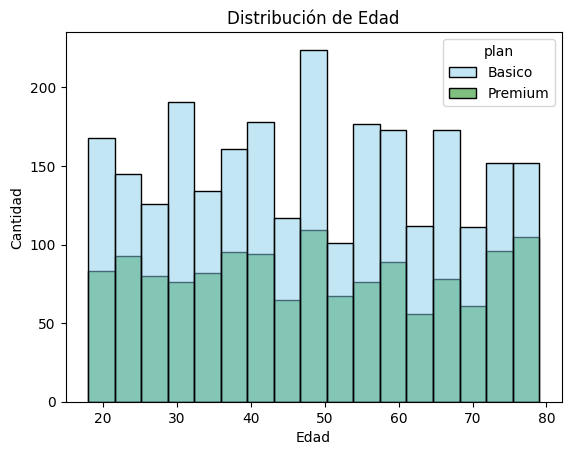

In [ ]:

# Histograma para visualizar la edad (age)


sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()





💡Insights:
- No existe una relación clara entre la edad y el tipo de plan tanto Básico como Premium tienen presencia en todos los grupos de edad.
Sin embargo, se observa que alrededor de los 50 años hay el mayor volumen de usuarios en plan Básico. Por otro lado, los usuarios mayores de 70 años muestran una proporción ligeramente mayor de plan Premium comparado con otros rangos de edad. Por lo que podemos decir que la distribución es simétrica.

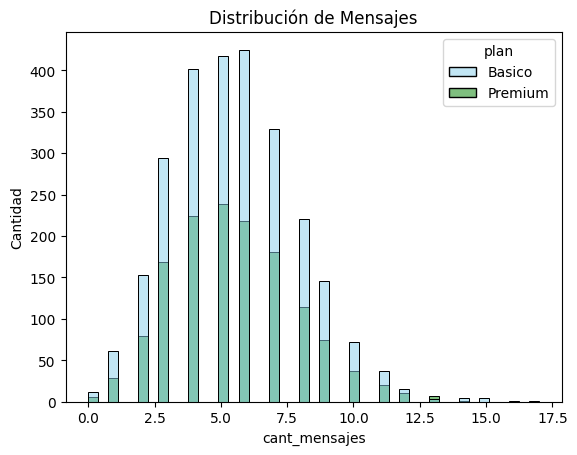

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Mensajes')
plt.xlabel('cant_mensajes')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Se observa que la distribución de mensajes está sesgada a la derecha, la mayoría de usuarios envía entre 3 y 7 mensajes y disminuye a partir de los 10 mensajes de texto en adelante.
Los usuarios con plan Premium son los que representan un mayor envio d mensajes (5-7), superando a los del plan Básico.
El pico de la distribución está entre 5 y 6 mensajes para ambos planes.

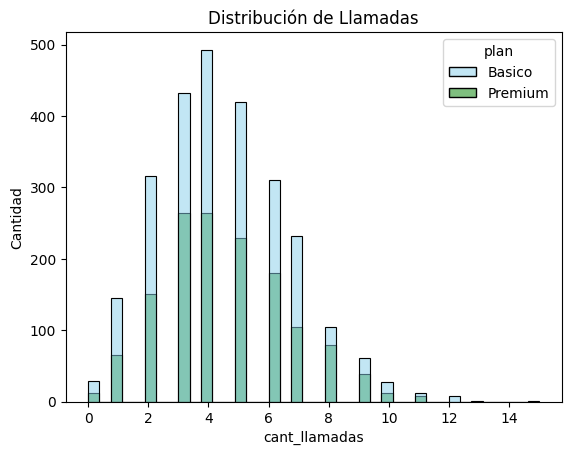

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Llamadas')
plt.xlabel('cant_llamadas')
plt.ylabel('Cantidad')
plt.show()


💡Insights:
- Se observa una distribución similar a los mensajes de texto; está sesgada a la derecha, la mayoría de usuarios envía entre 2 a 7 llamadas y disminuye a partir de la octava en adelante.
Los usuarios con plan Premium son los que representan un mayor número de llamadas (2-7).

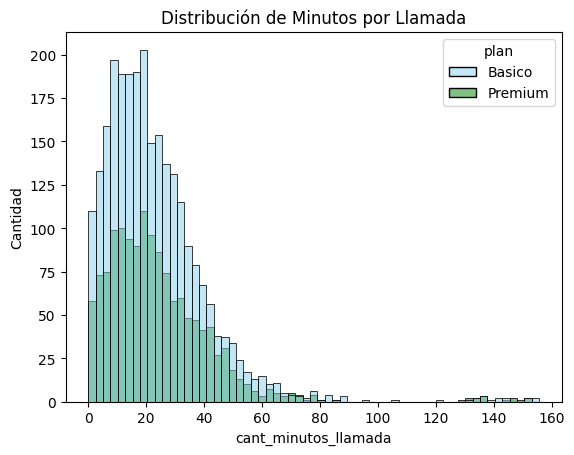

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Minutos por Llamada')
plt.xlabel('cant_minutos_llamada')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- La distribución de minutos de llamada está sesgada a la derecha la mayoría de usuarios acumula entre 10 y 25 minutos totales en llamadas, con muy pocos usuarios superando los 80 minutos.
Los usuarios con plan Premium tienen mayor presencia en los rangos altos (más de 40 minutos), lo que sugiere que hacen llamadas más largas o más frecuentes que los usuarios Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

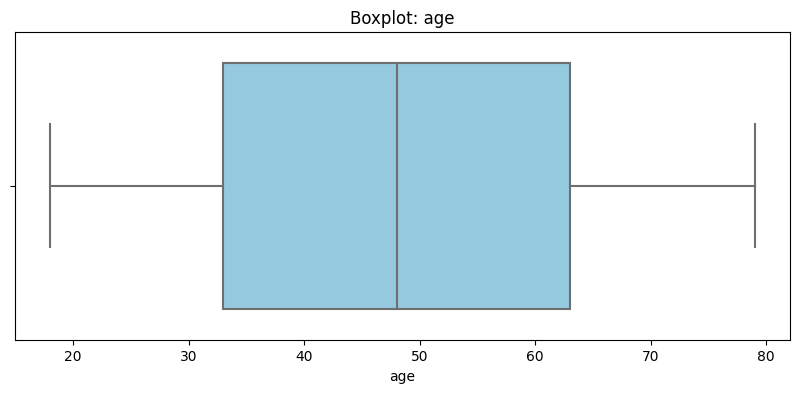

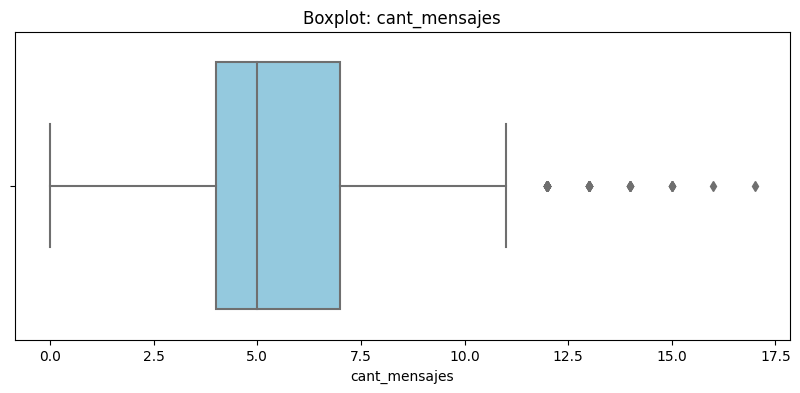

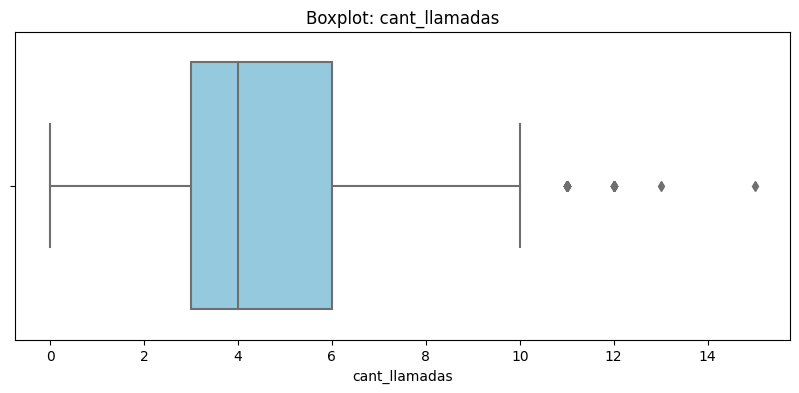

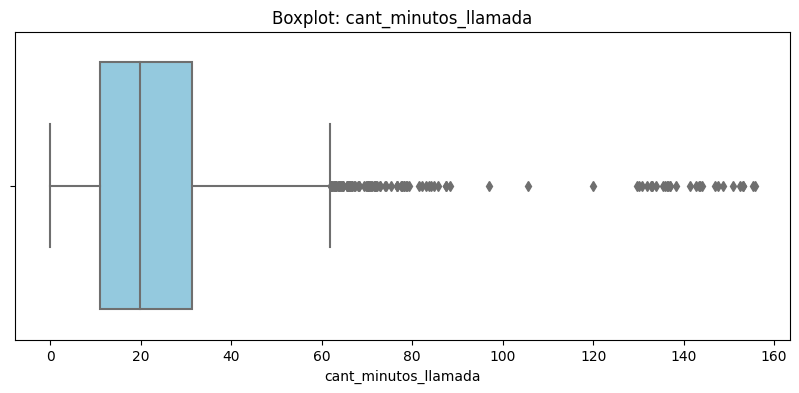

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta outliers
- cant_minutos_llamada: Presenta outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col  in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = user_profile[(user_profile[col] > limite_superior) | (user_profile[col] < limite_inferior)]
    print(f"{col} → outliers: {len(outliers)}")


age → outliers: 0
cant_mensajes → outliers: 46
cant_llamadas → outliers: 30
cant_minutos_llamada → outliers: 109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Se deben mantener ya que un usuario puede llegar a enviar 17 mensajes.
- cant_llamadas: mantener o no outliers, porqué? Se deben mantener ya que un usuario puede llegar a realizar 15 llamadas.
- cant_minutos_llamada: mantener o no outliers, porqué? Se deben mantener ya que pertenece a usuarios premium que realizan un mayor consumo de cantidad de minutos por llamada.

Lo que podemos concluir es que se deben mantener los 46 outliers ya que lo único que nos indica es el alto uso por usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:



# Crear columna grupo_uso
def classify_segment(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']


    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"


    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"


user_profile['grupo_uso'] = user_profile.apply(classify_segment, axis=1)
print(user_profile['grupo_uso'].value_counts())


Uso medio         2943
Bajo uso           778
Alto uso           278
Error en Datos       1
Name: grupo_uso, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def classify_segment(row):
    edad = row['age']


    if pd.isna(edad):
        return "Error en Datos"


    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"


user_profile['grupo_edad'] = user_profile.apply(classify_segment, axis=1)
print(user_profile['grupo_edad'].value_counts())


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

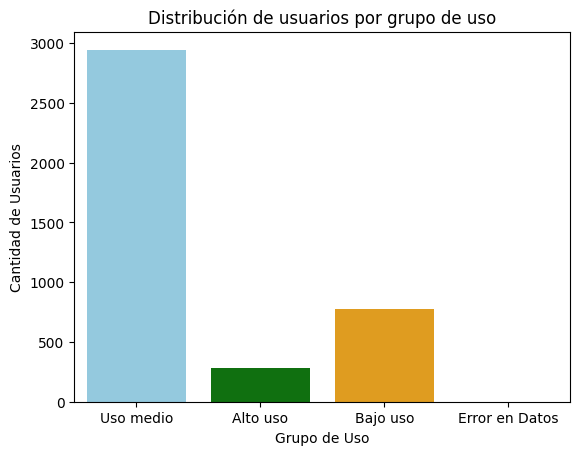

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

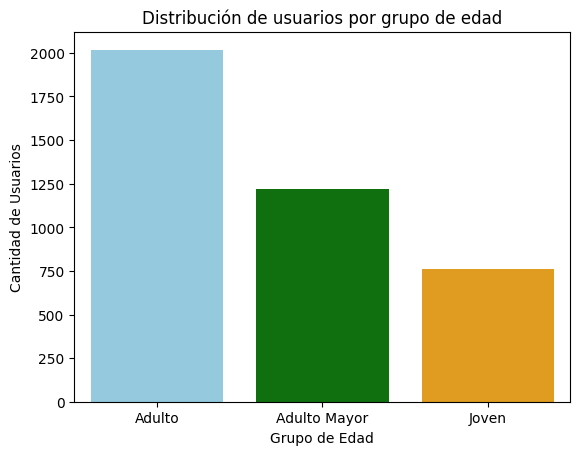

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?:
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- age contenía el sentinel -999 se reemplazo con la mediana, el cual representaba menos del 1% de los registros.
- city contenía el sentinel "?" y valores nulos NaN, representaban el 11.7% de los registros. Se imputaron con la moda.
- churn_date tenía el 88.3% de nulos no son datos faltantes sino usuarios activos.
- duration y length en usage tenían nulos MAR, dependen del tipo de registro (llamada o texto), por lo que se dejaron como nulos.


🔍 **Segmentos por Edad**
- No existe una relación clara entre la edad y el tipo de plan. Sin embargo, se observa que alrededor de los 50 años hay el mayor volumen de usuarios en plan Básico. Los usuarios mayores de 70 años muestran una proporción ligeramente mayor de plan Premium comparado con otros rangos de edad. En general, el plan Básico domina en todos los grupos de edad.


📊 **Segmentos por Nivel de Uso**
- Los usuarios de uso medio (entre 5 y 10 llamadas y mensajes) representan el segmento más numeroso. Los usuarios de alto uso corresponden principalmente al plan Premium, con mayor cantidad de minutos acumulados en llamadas. Los outliers encontrados en cant_mensajes, cant_llamadas y cant_minutos_llamada se mantienen ya que representan usuarios con comportamiento de alto consumo real la cúal es información valiosa para el negocio.

➡️ Esto sugiere que existe una oportunidad para migrar usuarios de uso medio del plan Básico al Premium, ofreciendo paquetes atractivos adaptados a su comportamiento de consumo.



💡 **Recomendaciones**
- Crear paquetes enfocados en el segmento adulto (30-60 años) que incluyan entre 5 y 10 llamadas y mensajes de texto, que es el rango de uso más frecuente.
- Diseñar una estrategia de migración de plan Básico a Premium para usuarios de uso medio, ofreciendo beneficios adicionales como minutos extra o mensajes ilimitados.
- Monitorear el segmento de alto uso, estos usuarios ya tienen comportamiento Premium y podrían ser candidatos a planes especializados con mayor consumo.
- Revisar por qué los usuarios mayores de 70 años prefieren ligeramente el plan Premium, podría existir una oportunidad de marketing dirigida a este grupo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`